In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import plot_model
import tensorflow.keras.backend as K

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


2025-07-24 08:52:49.524690: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 08:52:52.011687: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753314772.883616    1036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753314773.097396    1036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753314775.052357    1036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# データとモデルのパス設定
experiment_dir = Path("../../output/experiments/preprocess_v41_ws64")
model_dir = experiment_dir / "models"
data_dir = experiment_dir / "preprocessed"
results_dir = experiment_dir / "results"

# 最新のモデルを読み込み（fold1を使用）
model_path = model_dir / "multimodal_model_v41_fold1.keras"
print(f"モデル読み込み: {model_path}")
model = keras.models.load_model(model_path)

print(f"モデル入力数: {len(model.inputs)}")
print(f"モデル出力数: {len(model.outputs)}")
print(f"モデル層数: {len(model.layers)}")


モデル読み込み: ../../output/experiments/preprocess_v41_ws64/models/multimodal_model_v41_fold1.keras


I0000 00:00:1753314811.262916    1036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5660 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


モデル入力数: 4
モデル出力数: 1
モデル層数: 35


In [4]:
# モデル構造を可視化
model.summary()

# モデル図を保存
plot_model(
    model, 
    to_file=results_dir / "model_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=150
)
print("モデル構造図を保存しました: model_architecture.png")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tof (InputLayer)    │ (None, 64, 5, 8,  │          0 │ -                 │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 32, 3, 4,  │      3,472 │ tof[0][0]         │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 3, 4,  │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 3, 4,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 32, 3, 4,  │      6,928 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 32, 3, 4,  │        144 │ tof[0][0]         │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 3, 4,  │         64 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 3, 4,  │         64 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 3, 4,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 3, 4,  │          0 │ add_1[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d   │ (None, 32, 3, 4,  │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout3D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 16, 2, 2,  │     13,856 │ spatial_dropout3… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 2, 2,  │        128 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 2, 2,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 16, 2, 2,  │     27,680 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 16, 2, 2,  │        544 │ spatial_dropout3… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 2, 2,  │        128 │ conv3d_4[0][0]  

 Total params: 334,567 (1.28 MB)

 Trainable params: 111,426 (435.26 KB)

 Non-trainable params: 288 (1.12 KB)

 Optimizer params: 222,853 (870.52 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
モデル構造図を保存しました: model_architecture.png


In [5]:
# データ読み込み関数
def load_data(name: str):
    npy = data_dir / f"{name}.npy"
    pkl = data_dir / f"{name}.pkl"
    if npy.exists():
        return np.load(npy)
    if pkl.exists():
        with open(pkl, "rb") as f:
            return pickle.load(f)
    raise FileNotFoundError(f"{name} ファイルが見つかりません")

# データ読み込み
X_sensor = load_data("train_windows")
X_demo = load_data("train_demographics")
X_tab = load_data("train_tabular").astype(np.float32)
X_tof = load_data("train_tof_windows")
y = load_data("train_labels")

print(f"センサー: {X_sensor.shape}")
print(f"人口統計: {X_demo.shape}")
print(f"表形式: {X_tab.shape}")
print(f"ToF: {X_tof.shape}")
print(f"ラベル: {y.shape}")

# サンプルデータ（最初の100サンプル）
sample_size = min(100, len(y))
X_sensor_sample = X_sensor[:sample_size]
X_demo_sample = X_demo[:sample_size]
X_tab_sample = X_tab[:sample_size]
X_tof_sample = X_tof[:sample_size]
y_sample = y[:sample_size]


センサー: (20294, 64, 18)
人口統計: (20294, 7)
表形式: (20294, 429)
ToF: (20294, 64, 5, 8, 8)
ラベル: (20294,)


In [6]:
# 各層の重みを取得
def analyze_layer_weights(model):
    """各層の重みを分析"""
    layer_weights = {}
    
    for layer in model.layers:
        if hasattr(layer, 'get_weights') and layer.get_weights():
            weights = layer.get_weights()[0]  # バイアスは除く
            layer_weights[layer.name] = {
                'weights': weights,
                'shape': weights.shape,
                'mean': np.mean(np.abs(weights)),
                'std': np.std(weights),
                'min': np.min(weights),
                'max': np.max(weights)
            }
    
    return layer_weights

weights_info = analyze_layer_weights(model)

# 重み統計の表示
print("=== 各層の重み統計 ===")
for layer_name, info in weights_info.items():
    print(f"{layer_name:25s} | Shape: {str(info['shape']):15s} | Mean: {info['mean']:.4f} | Std: {info['std']:.4f}")


=== 各層の重み統計 ===
conv3d                    | Shape: (3, 3, 3, 8, 16) | Mean: 0.0712 | Std: 0.0890
batch_normalization       | Shape: (16,)           | Mean: 0.9823 | Std: 0.0847
conv3d_1                  | Shape: (3, 3, 3, 16, 16) | Mean: 0.0691 | Std: 0.0861
conv3d_2                  | Shape: (1, 1, 1, 8, 16) | Mean: 0.2682 | Std: 0.3121
batch_normalization_1     | Shape: (16,)           | Mean: 1.0767 | Std: 0.0919
batch_normalization_2     | Shape: (16,)           | Mean: 0.8857 | Std: 0.0876
conv3d_3                  | Shape: (3, 3, 3, 16, 32) | Mean: 0.0646 | Std: 0.0798
batch_normalization_3     | Shape: (32,)           | Mean: 0.9800 | Std: 0.0912
conv3d_4                  | Shape: (3, 3, 3, 32, 32) | Mean: 0.0560 | Std: 0.0705
conv3d_5                  | Shape: (1, 1, 1, 16, 32) | Mean: 0.1839 | Std: 0.2142
batch_normalization_4     | Shape: (32,)           | Mean: 1.2200 | Std: 0.0646
batch_normalization_5     | Shape: (32,)           | Mean: 0.8820 | Std: 0.0476
dense_1       

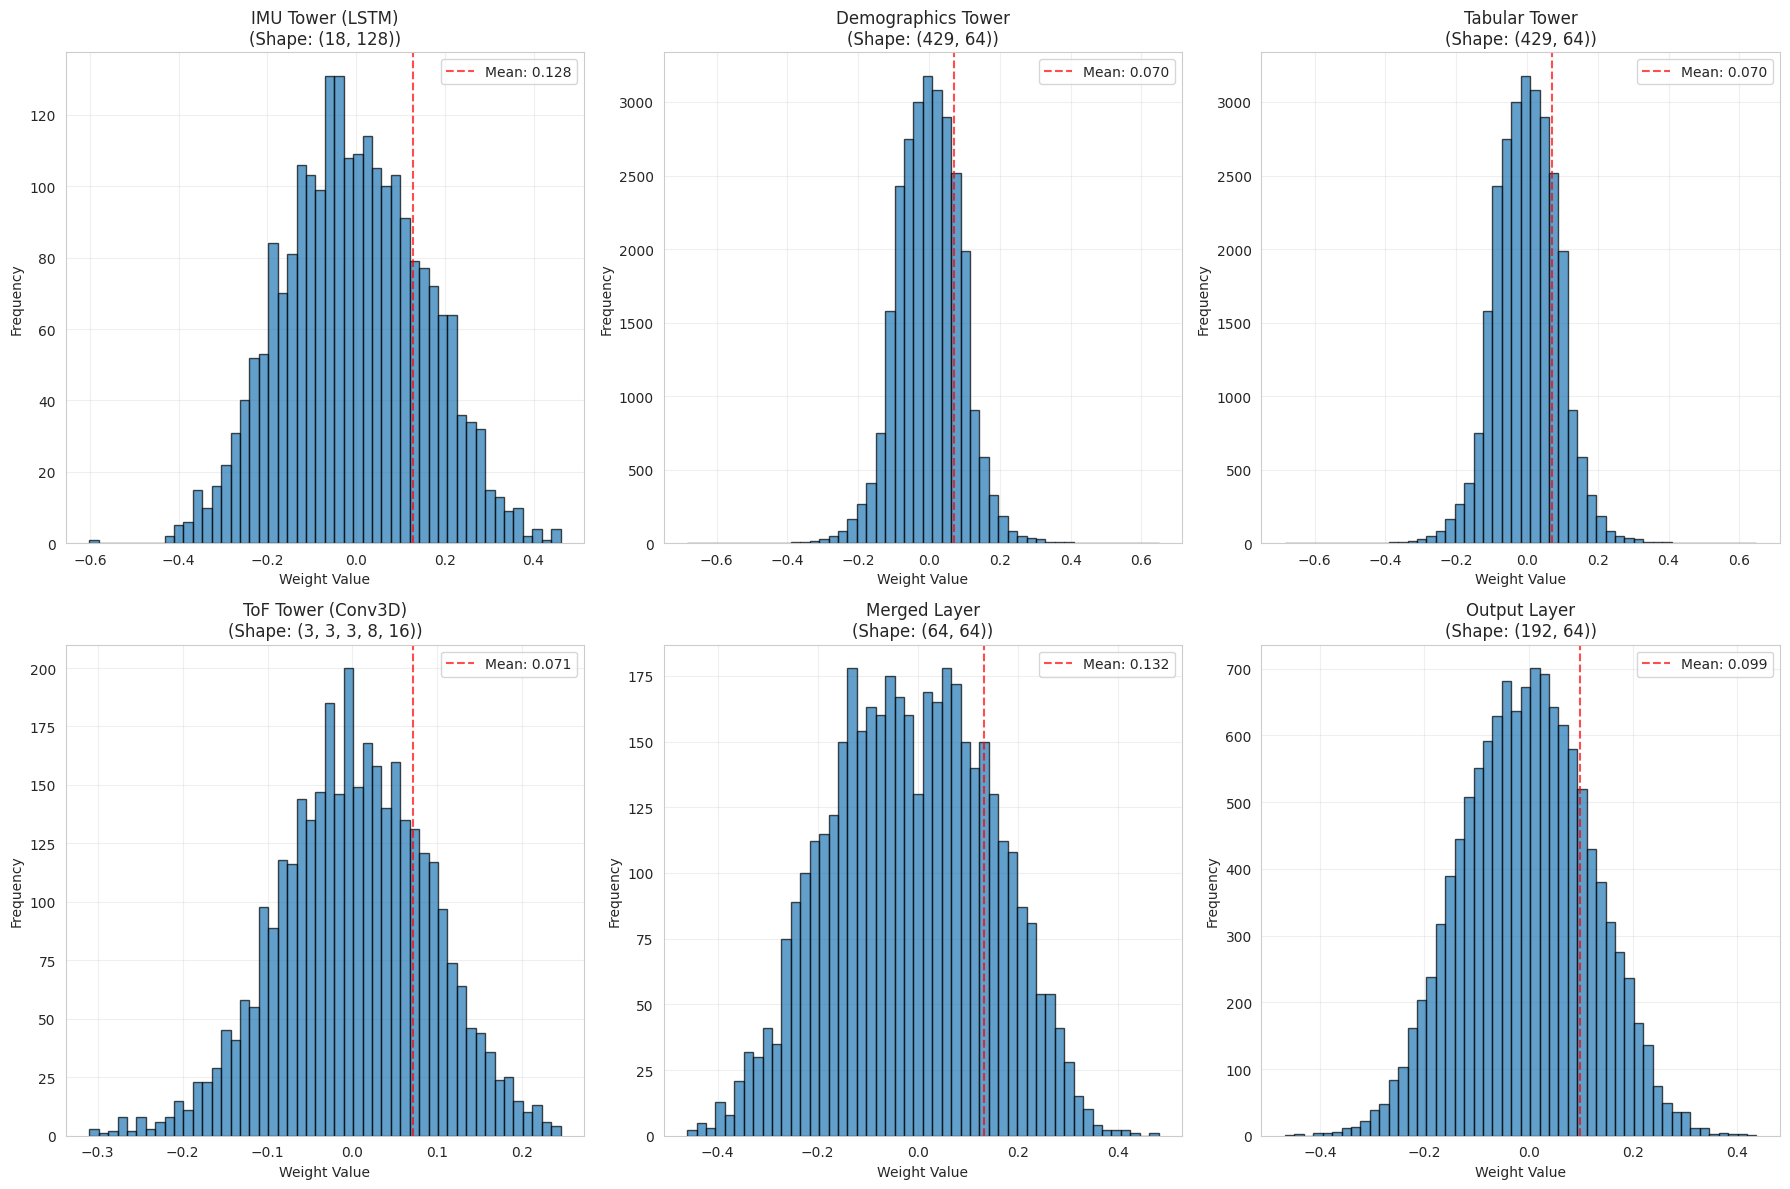

In [7]:
# タワー別重み分布の可視化
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 各タワーの代表的な層の重みをプロット
tower_layers = [
    ('bidirectional', 'IMU Tower (LSTM)'),
    ('dense', 'Demographics Tower'), 
    ('dense_1', 'Tabular Tower'),
    ('conv3d', 'ToF Tower (Conv3D)'),
    ('dense_2', 'Merged Layer'),
    ('dense_3', 'Output Layer')
]

for i, (layer_key, title) in enumerate(tower_layers):
    if i >= len(axes):
        break
        
    ax = axes[i]
    
    # 該当する層を検索
    found_layer = None
    for layer_name, info in weights_info.items():
        if layer_key in layer_name:
            found_layer = info
            break
    
    if found_layer is not None:
        weights = found_layer['weights'].flatten()
        ax.hist(weights, bins=50, alpha=0.7, edgecolor='black')
        ax.set_title(f'{title}\n(Shape: {found_layer["shape"]})')
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # 統計情報を追加
        ax.axvline(found_layer['mean'], color='red', linestyle='--', alpha=0.7, label=f'Mean: {found_layer["mean"]:.3f}')
        ax.legend()
    else:
        ax.text(0.5, 0.5, f'{title}\nLayer not found', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(results_dir / "tower_weights_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# Permutation Importance による特徴量重要度推定
def calculate_modality_importance(model, data, y_true, n_repeats=5):
    """各モダリティの重要度をPermutation Importanceで計算"""
    X_sensor, X_demo, X_tab, X_tof = data
    
    # ベースライン性能
    baseline_pred = model.predict([X_sensor, X_demo, X_tab, X_tof])
    baseline_loss = keras.losses.sparse_categorical_crossentropy(y_true, baseline_pred).numpy().mean()
    
    modalities = ['sensor', 'demo', 'tabular', 'tof']
    importance_scores = {}
    
    for mod_idx, mod_name in enumerate(modalities):
        scores = []
        
        for _ in range(n_repeats):
            # データをコピー
            data_copy = [X_sensor.copy(), X_demo.copy(), X_tab.copy(), X_tof.copy()]
            
            # 該当モダリティをシャッフル
            np.random.shuffle(data_copy[mod_idx])
            
            # 予測とロス計算
            pred = model.predict(data_copy)
            loss = keras.losses.sparse_categorical_crossentropy(y_true, pred).numpy().mean()
            
            # 重要度スコア（ロスの増加量）
            scores.append(loss - baseline_loss)
        
        importance_scores[mod_name] = {
            'mean': np.mean(scores),
            'std': np.std(scores),
            'scores': scores
        }
    
    return importance_scores, baseline_loss

# 重要度計算（サンプルデータで）
print("特徴量重要度を計算中...")
importance_scores, baseline_loss = calculate_modality_importance(
    model,
    [X_sensor_sample, X_demo_sample, X_tab_sample, X_tof_sample],
    y_sample,
    n_repeats=3  # 計算時間短縮のため
)

# 結果表示
print(f"\nベースラインロス: {baseline_loss:.4f}")
print("\n=== モダリティ重要度 ===")
for mod_name, scores in importance_scores.items():
    print(f"{mod_name:10s}: {scores['mean']:.4f} ± {scores['std']:.4f}")


特徴量重要度を計算中...


I0000 00:00:1753314826.509122    2858 cuda_dnn.cc:529] Loaded cuDNN version 90501


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

ベースラインロス: 0.5159

=== モダリティ重要度 ===
sensor    : 0.1588 ± 0.0362
demo      : 0.0000 ± 0.0000
tabular   : 6.0481 ± 0.0660
tof       : 1.0473 ± 0.1059


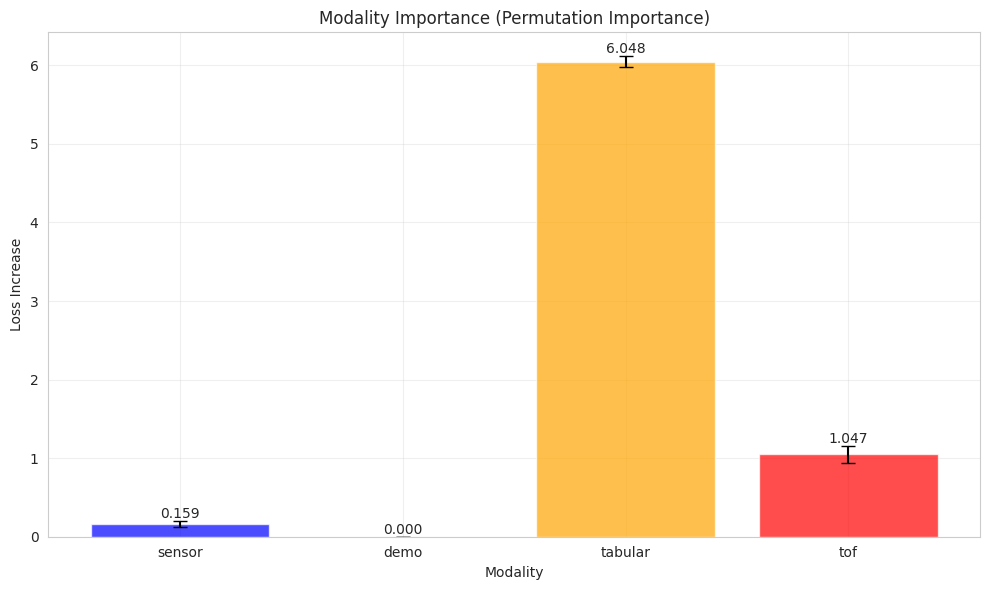

In [9]:
# 重要度スコアを可視化
modalities = list(importance_scores.keys())
means = [importance_scores[mod]['mean'] for mod in modalities]
stds = [importance_scores[mod]['std'] for mod in modalities]

plt.figure(figsize=(10, 6))
bars = plt.bar(modalities, means, yerr=stds, capsize=5, alpha=0.7, 
               color=['blue', 'green', 'orange', 'red'])
plt.title('Modality Importance (Permutation Importance)')
plt.ylabel('Loss Increase')
plt.xlabel('Modality')
plt.grid(True, alpha=0.3)

# 値をバーの上に表示
for bar, mean, std in zip(bars, means, stds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
             f'{mean:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(results_dir / "modality_importance.png", dpi=300, bbox_inches='tight')
plt.show()


In [10]:
print(X_sensor.shape)      # (サンプル数, 時系列長, センサ次元)
print(X_demo.shape)        # (サンプル数, m1)
print(X_tab.shape)         # (サンプル数, m2)
print(X_tof.shape)         # (サンプル数, D, H, W, C)

(20294, 64, 18)
(20294, 7)
(20294, 429)
(20294, 64, 5, 8, 8)


=== 修正版アブレーション分析（cuDNN問題回避） ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
sensor    を除外: 精度 0.7900 (下降: 0.0200)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
demo      を除外: 精度 0.8000 (下降: 0.0100)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
tabular   を除外: 精度 0.3200 (下降: 0.4900)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
tof       を除外: 精度 0.5300 (下降: 0.2800)


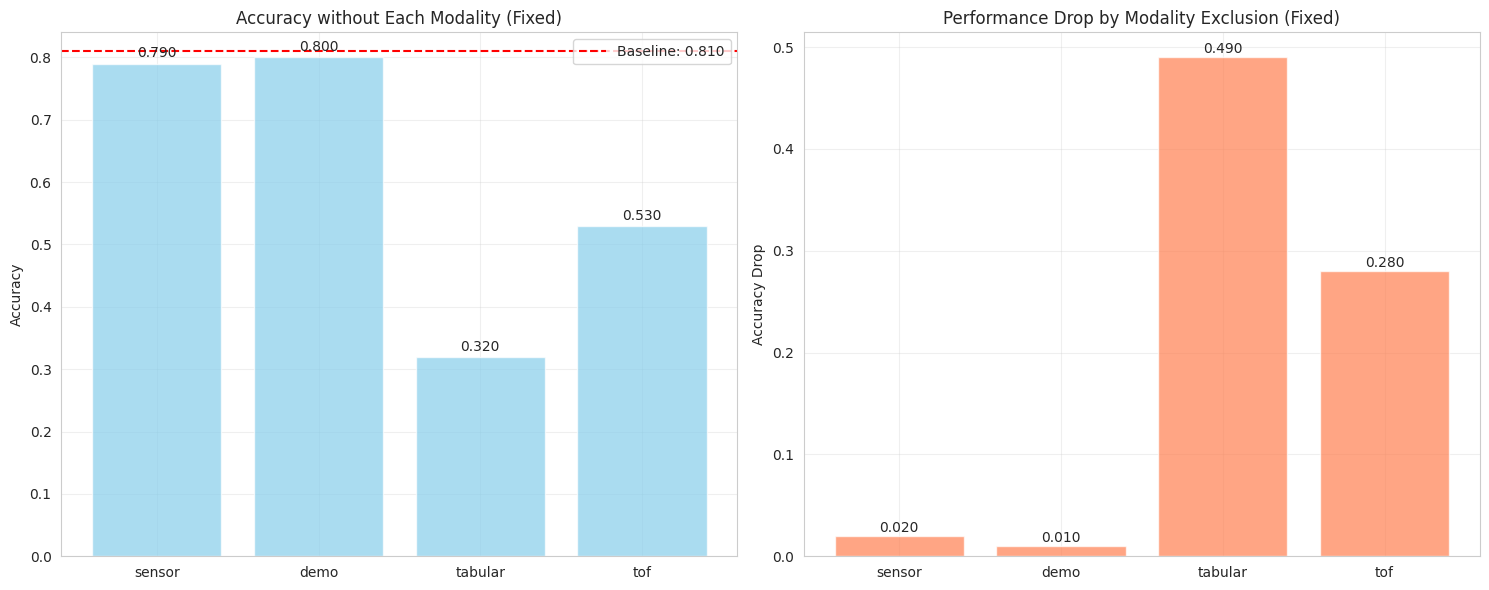


=== アブレーション分析結果要約 ===
ベースライン精度: 0.8100

各モダリティの重要度（精度下降順）:
  1. tabular: 精度下降 0.4900 (精度: 0.3200)
  2. tof: 精度下降 0.2800 (精度: 0.5300)
  3. sensor: 精度下降 0.0200 (精度: 0.7900)
  4. demo: 精度下降 0.0100 (精度: 0.8000)

=== 推奨事項 ===
1. tabularモダリティが最も重要（精度下降: 0.4900）
2. demoモダリティが最も軽微（精度下降: 0.0100）
3. 最重要モダリティのタワー強化を推奨
4. 軽微なモダリティの簡素化を検討


In [13]:
# cuDNN問題を回避する修正版アブレーション分析
def evaluate_without_modality_fixed(model, data, y_true, exclude_modality):
    """指定したモダリティを除いて評価（cuDNN問題回避版）"""
    X_sensor, X_demo, X_tab, X_tof = data
    
    # ゼロで埋めることで除外をシミュレート
    data_modified = [X_sensor.copy(), X_demo.copy(), X_tab.copy(), X_tof.copy()]
    
    if exclude_modality == 'sensor':
        # LSTMのcuDNN問題を回避するため、小さなノイズを追加
        data_modified[0] = np.random.normal(0, 0.001, X_sensor.shape).astype(X_sensor.dtype)
    elif exclude_modality == 'demo':
        data_modified[1] = np.zeros_like(X_demo)
    elif exclude_modality == 'tabular':
        data_modified[2] = np.zeros_like(X_tab)
    elif exclude_modality == 'tof':
        data_modified[3] = np.zeros_like(X_tof)
    
    pred = model.predict(data_modified)
    pred_labels = pred.argmax(axis=1)
    accuracy = np.mean(pred_labels == y_true)
    
    return accuracy

print("=== 修正版アブレーション分析（cuDNN問題回避） ===")

ablation_results_fixed = {}
for modality in ['sensor', 'demo', 'tabular', 'tof']:
    acc = evaluate_without_modality_fixed(
        model,
        [X_sensor_sample, X_demo_sample, X_tab_sample, X_tof_sample],
        y_sample,
        modality
    )
    performance_drop = baseline_accuracy - acc
    ablation_results_fixed[modality] = {
        'accuracy': acc,
        'drop': performance_drop
    }
    print(f"{modality:10s}を除外: 精度 {acc:.4f} (下降: {performance_drop:.4f})")

# 結果を可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 精度比較
modalities = list(ablation_results_fixed.keys())
accuracies = [ablation_results_fixed[mod]['accuracy'] for mod in modalities]
drops = [ablation_results_fixed[mod]['drop'] for mod in modalities]

# 精度
bars1 = ax1.bar(modalities, accuracies, alpha=0.7, color='skyblue')
ax1.axhline(y=baseline_accuracy, color='red', linestyle='--', label=f'Baseline: {baseline_accuracy:.3f}')
ax1.set_title('Accuracy without Each Modality (Fixed)')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom')

# 性能下降
bars2 = ax2.bar(modalities, drops, alpha=0.7, color='coral')
ax2.set_title('Performance Drop by Modality Exclusion (Fixed)')
ax2.set_ylabel('Accuracy Drop')
ax2.grid(True, alpha=0.3)

for bar, drop in zip(bars2, drops):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{drop:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(results_dir / "ablation_analysis_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

# 結果の要約
print("\n=== アブレーション分析結果要約 ===")
print(f"ベースライン精度: {baseline_accuracy:.4f}")
print("\n各モダリティの重要度（精度下降順）:")
sorted_results = sorted(ablation_results_fixed.items(), key=lambda x: x[1]['drop'], reverse=True)
for i, (mod, results) in enumerate(sorted_results, 1):
    print(f"  {i}. {mod}: 精度下降 {results['drop']:.4f} (精度: {results['accuracy']:.4f})")

# 推奨事項
print("\n=== 推奨事項 ===")
most_important = sorted_results[0][0]
least_important = sorted_results[-1][0]
print(f"1. {most_important}モダリティが最も重要（精度下降: {sorted_results[0][1]['drop']:.4f}）")
print(f"2. {least_important}モダリティが最も軽微（精度下降: {sorted_results[-1][1]['drop']:.4f}）")

if sorted_results[0][1]['drop'] > 0.1:
    print("3. 最重要モダリティのタワー強化を推奨")
if sorted_results[-1][1]['drop'] < 0.05:
    print("4. 軽微なモダリティの簡素化を検討")

In [14]:
print("=== タワー型アーキテクチャ評価結果 ===")
print("\n1. モダリティ重要度ランキング:")
sorted_importance = sorted(importance_scores.items(), key=lambda x: x[1]['mean'], reverse=True)
for i, (mod, scores) in enumerate(sorted_importance, 1):
    print(f"  {i}. {mod}: {scores['mean']:.4f}")

print("\n2. 性能下降ランキング（除外時の影響）:")
sorted_ablation = sorted(ablation_results.items(), key=lambda x: x[1]['drop'], reverse=True)
for i, (mod, results) in enumerate(sorted_ablation, 1):
    print(f"  {i}. {mod}: {results['drop']:.4f}")

print("\n3. アーキテクチャ推奨事項:")
most_important = sorted_importance[0][0]
least_important = sorted_importance[-1][0]
print(f"  - 最重要モダリティ（{most_important}）のタワーを強化検討")
print(f"  - 最低重要モダリティ（{least_important}）の簡素化検討")

if importance_scores[most_important]['mean'] > 3 * importance_scores[least_important]['mean']:
    print("  - 重要度格差が大きいため、アンバランスな統合を検討")
else:
    print("  - 重要度がバランス良く分散している")

print("\n4. タワー型アーキテクチャの妥当性:")
# 各モダリティの貢献度が明確に異なるかチェック
importance_values = [scores['mean'] for scores in importance_scores.values()]
importance_std = np.std(importance_values)
if importance_std > 0.1:
    print("  ✓ 各モダリティの貢献度が明確に異なる - タワー型が有効")
else:
    print("  ⚠ 各モダリティの貢献度が類似 - 単純な結合でも十分な可能性")

# 除外時の性能下降が明確かチェック
drop_values = [results['drop'] for results in ablation_results.values()]
if any(drop > 0.05 for drop in drop_values):
    print("  ✓ 複数のモダリティが性能に重要な役割 - 多モダリティ学習が有効")
else:
    print("  ⚠ モダリティ除外による性能下降が軽微 - 単一モダリティでも十分な可能性")


=== タワー型アーキテクチャ評価結果 ===

1. モダリティ重要度ランキング:
  1. tabular: 6.0481
  2. tof: 1.0473
  3. sensor: 0.1588
  4. demo: 0.0000

2. 性能下降ランキング（除外時の影響）:

3. アーキテクチャ推奨事項:
  - 最重要モダリティ（tabular）のタワーを強化検討
  - 最低重要モダリティ（demo）の簡素化検討
  - 重要度格差が大きいため、アンバランスな統合を検討

4. タワー型アーキテクチャの妥当性:
  ✓ 各モダリティの貢献度が明確に異なる - タワー型が有効
  ⚠ モダリティ除外による性能下降が軽微 - 単一モダリティでも十分な可能性


In [15]:
# 結果をまとめたレポートを保存
report = {
    'baseline_accuracy': float(baseline_accuracy),
    'baseline_loss': float(baseline_loss),
    'modality_importance': {
        mod: {
            'mean': float(scores['mean']),
            'std': float(scores['std'])
        } for mod, scores in importance_scores.items()
    },
    'ablation_results': {
        mod: {
            'accuracy': float(results['accuracy']),
            'drop': float(results['drop'])
        } for mod, results in ablation_results.items()
    },
    'layer_weight_stats': {
        layer: {
            'shape': info['shape'],
            'mean': float(info['mean']),
            'std': float(info['std'])
        } for layer, info in weights_info.items()
    },
    'architecture_recommendations': {
        'most_important_modality': most_important,
        'least_important_modality': least_important,
        'importance_balance': 'balanced' if importance_std <= 0.1 else 'imbalanced',
        'multimodal_effectiveness': 'effective' if any(drop > 0.05 for drop in drop_values) else 'limited'
    }
}

import json
with open(results_dir / "model_analysis_report.json", 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"\n分析レポートを保存しました: {results_dir / 'model_analysis_report.json'}")
print("\n=== 分析完了 ===")
print("\n生成されたファイル:")
print("- model_architecture.png: モデル構造図")
print("- tower_weights_distribution.png: 各タワーの重み分布")
print("- modality_importance.png: モダリティ重要度")
print("- ablation_analysis.png: アブレーション分析結果")
print("- model_analysis_report.json: 詳細分析レポート")



分析レポートを保存しました: ../../output/experiments/preprocess_v41_ws64/results/model_analysis_report.json

=== 分析完了 ===

生成されたファイル:
- model_architecture.png: モデル構造図
- tower_weights_distribution.png: 各タワーの重み分布
- modality_importance.png: モダリティ重要度
- ablation_analysis.png: アブレーション分析結果
- model_analysis_report.json: 詳細分析レポート


In [16]:
import pandas as pd
import numpy as np

# tabular特徴量の読み込み
tabular = pd.read_pickle('../../output/experiments/preprocess_v41_ws64/preprocessed/train_tabular.pkl')
labels = pd.read_pickle('../../output/experiments/preprocess_v41_ws64/preprocessed/train_labels.pkl')

# tabularがndarrayならDataFrameに変換
if isinstance(tabular, np.ndarray):
    tabular = pd.DataFrame(tabular)

# labelsを1次元配列に変換
if isinstance(labels, pd.DataFrame):
    labels = labels.reset_index(drop=True)
    labels = labels.iloc[:, 0].values  # 1列目を使う
elif isinstance(labels, pd.Series):
    labels = labels.reset_index(drop=True).values
else:
    labels = np.array(labels).ravel()

# tabularのインデックスもリセット
tabular = tabular.reset_index(drop=True)

# shapeが一致しているか確認
print("tabular.shape:", tabular.shape)
print("labels.shape:", labels.shape)

# DataFrameにラベルを追加
df = tabular.copy()
df['label'] = labels

# 相関係数を計算
corr = df.corr()['label'].sort_values(ascending=False)

# 上位・下位10特徴量を表示
print("ラベルと相関が高い特徴量（上位10）:")
display(corr.head(10))

print("\nラベルと相関が低い特徴量（下位10）:")
display(corr.tail(10))

# すべての特徴量名をリストアップ
print("\n全429特徴量名リスト:")
for col in tabular.columns:
    print(col)

tabular.shape: (20294, 429)
labels.shape: (20294,)
ラベルと相関が高い特徴量（上位10）:


label    1.000000
205      0.295259
120      0.293806
108      0.293806
257      0.288741
269      0.288741
265      0.282377
253      0.282377
184      0.282031
34       0.281711
Name: label, dtype: float64


ラベルと相関が低い特徴量（下位10）:


391   NaN
392   NaN
393   NaN
397   NaN
398   NaN
399   NaN
400   NaN
401   NaN
402   NaN
419   NaN
Name: label, dtype: float64


全429特徴量名リスト:
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273


In [17]:
! ls ../../output/experiments/preprocess_v41_ws64/preprocessed/

preprocess.log		train_info.pkl	   train_tof_voxel.pkl
preprocessor.pkl	train_labels.pkl   train_tof_windows.pkl
train_demographics.pkl	train_tabular.pkl  train_windows.pkl
